# Predictive validity tutorial #3

### Similarity of prospective data over time

The report of `evaluate_pv()` (tutorials #1 and #2) includes a chart of how similar the prospective compounds of each model version are to everything predicted before them: similarity of the data, of the correlations and of the structures. This notebook draws that chart on its own with `Plotter.plot_time_weighted_scores()`, first as in the report and then with optional settings for a figure.\
It uses the hLM CLint endpoint of the data set from tutorial #2.

In [1]:
import os
import pandas as pd
from mosses.core import metrics
from mosses.core.plotter import Plotter

In [2]:
# Load dataframe from path
data_dir = os.path.join("data")
data = pd.read_csv(os.path.join(data_dir, "multi_objective_validation_1.csv"))

The curves are computed as in `evaluate_pv()`: the experimental and predicted values go into the columns `observed` and `predicted`, the training compounds stay in the comparison, and R² and RMSE count the prospective compounds only. The SMILES are found automatically in the column `structure`; pass `structure_col` if yours is named differently. `merge_months=True` pools model versions released in the same month, as in the report.

In [3]:
hlm = data.dropna(subset=["hlm_clint_exp", "hlm_clint_pred"])
hlm = hlm.assign(observed=hlm["hlm_clint_exp"], predicted=hlm["hlm_clint_pred"])
prospective = hlm.index[hlm["hlm_clint_set_split"] != "train"]

settings = dict(
    df=hlm,
    model_version_col="hlm_clint_model_version",
    scale="log",
    merge_months=True,
    prospective_index=prospective,
)
t_labels, scores, w_scores, struct_scores, r2_scores = metrics.compute_time_weighted_scores(
    discount_factor=0.9, **settings
)
rmse_scores = metrics.compute_rmse_over_time(**settings)

## 1. As in the report of `evaluate_pv()`

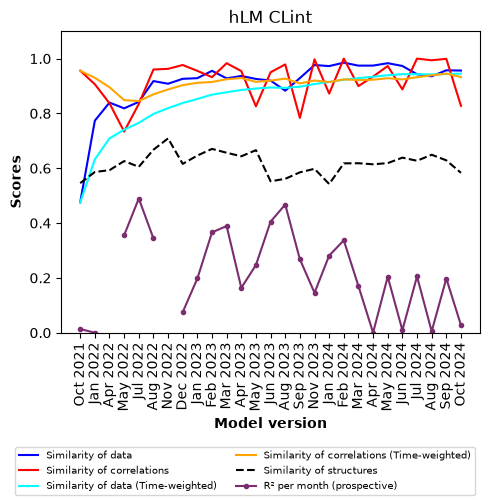

In [4]:
fig = Plotter().plot_time_weighted_scores(
    t_labels,
    scores,
    w_scores,
    "hLM CLint",
    struct_scores=struct_scores,
    r2_scores=r2_scores,
)

## 2. For a figure

The same function with optional settings: `w_scores=None` leaves out the time-weighted curves, R² is left out by not passing `r2_scores`, `rmse_scores` adds the RMSE of the same compounds, and `max_labels` sets how many x labels are shown.

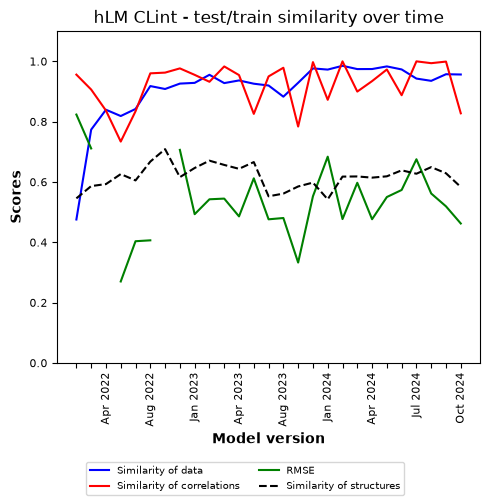

In [5]:
fig = Plotter().plot_time_weighted_scores(
    t_labels,
    scores,
    None,
    "hLM CLint - test/train similarity over time",
    struct_scores=struct_scores,
    rmse_scores=rmse_scores,
    max_labels=11,
)

When the similarity of data or of correlations drops while the similarity of structures stays level, the prospective compounds are chemically ordinary and the change comes from the data. A drop in the similarity of structures means the project has moved into new chemistry. The RMSE has gaps in April and November 2022, months with fewer than 5 prospective compounds.

The numbers behind the chart:

In [6]:
pd.DataFrame(
    {
        "model_version": t_labels,
        "similarity_of_data": scores[:, 0],
        "similarity_of_correlations": scores[:, 1],
        "similarity_of_structures": struct_scores,
        "rmse": rmse_scores,
        "r2": r2_scores,
    }
).round(2)

,model_version,similarity_of_data,similarity_of_correlations,similarity_of_structures,rmse,r2
0,Oct 2021,0.48,0.96,0.55,0.82,0.01
1,Jan 2022,0.77,0.91,0.59,0.71,0.00
2,Apr 2022,0.84,0.84,0.59,NaN,NaN
3,May 2022,0.82,0.73,0.63,0.27,0.36
4,Jul 2022,0.84,0.83,0.61,0.40,0.49
5,Aug 2022,0.92,0.96,0.67,0.41,0.34
6,Nov 2022,0.91,0.96,0.71,NaN,NaN
7,Dec 2022,0.93,0.98,0.62,0.71,0.08
8,Jan 2023,0.93,0.96,0.65,0.49,0.20
9,Feb 2023,0.96,0.93,0.67,0.54,0.37


Save the figure with e.g. `fig.savefig("similarity.pdf")`. With `merge_months=False` every model version gets its own point.